
# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


In [15]:
import pandas as pd

df = pd.read_csv("imdb_1000_reviews_cleaned.csv")

print(df.head())
print(df.columns)

                                              Review  \
0  The storyline was weak but performances were d...   
1  The storyline was weak but performances were d...   
2  Fantastic direction and brilliant cinematography.   
3                    One of the best movies of 2024.   
4  The storyline was weak but performances were d...   

                                clean_text  
0             storylin weak perform decent  
1             storylin weak perform decent  
2  fantast direct brilliant cinematographi  
3                            one best movi  
4             storylin weak perform decent  
Index(['Review', 'clean_text'], dtype='object')


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [16]:
# ==============================
# QUESTION 1 - NGRAM ANALYSIS
# ==============================

import re
from collections import defaultdict
import pandas as pd

# Load dataset (already uploaded)
df = pd.read_csv("imdb_1000_reviews_cleaned.csv")

# Use cleaned text column
documents = df['clean_text'].tolist()

# -----------------------------
# Preprocessing
# -----------------------------
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# -----------------------------
# Generate N-grams
# -----------------------------
def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

bigram_counts = defaultdict(int)
trigram_counts = defaultdict(int)
unigram_counts = defaultdict(int)

# Count frequencies
for doc in documents:
    tokens = preprocess(doc)

    for word in tokens:
        unigram_counts[word] += 1

    for bg in get_ngrams(tokens, 2):
        bigram_counts[bg] += 1

    for tg in get_ngrams(tokens, 3):
        trigram_counts[tg] += 1

# -----------------------------
# Bigram Probabilities
# -----------------------------
bigram_prob = {}

for (w1, w2), count in bigram_counts.items():
    if unigram_counts[w1] > 0:
        bigram_prob[(w1, w2)] = count / unigram_counts[w1]

# -----------------------------
# Print Results
# -----------------------------
print("Top 10 Bigrams:")
print(sorted(bigram_counts.items(), key=lambda x: x[1], reverse=True)[:10])

print("\nTop 10 Trigrams:")
print(sorted(trigram_counts.items(), key=lambda x: x[1], reverse=True)[:10])

print("\nTop 10 Bigram Probabilities:")
print(sorted(bigram_prob.items(), key=lambda x: x[1], reverse=True)[:10])

Top 10 Bigrams:
[(('storylin', 'weak'), 208), (('weak', 'perform'), 208), (('perform', 'decent'), 208), (('fantast', 'direct'), 204), (('direct', 'brilliant'), 204), (('brilliant', 'cinematographi'), 204), (('enjoy', 'pace'), 204), (('pace', 'film'), 204), (('movi', 'absolut'), 198), (('absolut', 'amaz'), 198)]

Top 10 Trigrams:
[(('storylin', 'weak', 'perform'), 208), (('weak', 'perform', 'decent'), 208), (('fantast', 'direct', 'brilliant'), 204), (('direct', 'brilliant', 'cinematographi'), 204), (('enjoy', 'pace', 'film'), 204), (('movi', 'absolut', 'amaz'), 198), (('absolut', 'amaz', 'visual'), 198), (('amaz', 'visual', 'stun'), 198), (('one', 'best', 'movi'), 186)]

Top 10 Bigram Probabilities:
[(('storylin', 'weak'), 1.0), (('weak', 'perform'), 1.0), (('perform', 'decent'), 1.0), (('fantast', 'direct'), 1.0), (('direct', 'brilliant'), 1.0), (('brilliant', 'cinematographi'), 1.0), (('one', 'best'), 1.0), (('best', 'movi'), 1.0), (('absolut', 'amaz'), 1.0), (('amaz', 'visual'), 1.0)

In [17]:
# ==============================
# NOUN PHRASE EXTRACTION
# ==============================

!python -m spacy download en_core_web_sm

import spacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")

noun_phrases_all = []

for doc in documents:
    doc_nlp = nlp(doc)
    noun_phrases = [chunk.text.lower() for chunk in doc_nlp.noun_chunks]
    noun_phrases_all.append(noun_phrases)

# Unique noun phrases
unique_nps = list(set([np for sublist in noun_phrases_all for np in sublist]))

# Create matrix
matrix = []

for nps in noun_phrases_all:
    row = []
    for np in unique_nps:
        row.append(nps.count(np))
    matrix.append(row)

df_noun = pd.DataFrame(matrix, columns=unique_nps)

print(df_noun.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 5.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   visual stun  one best movi  pace film  direct brilliant cinematographi
0            0              0          0                                0
1            0              0          0                                0
2            0              0          0                                1
3            0              1          0                                0
4            0              0          0                                0


## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [18]:
# ==============================
# QUESTION 2 - TF-IDF FROM SCRATCH
# ==============================

import math
import re
from collections import Counter

# Use your cleaned text
documents = df['clean_text'].tolist()

# -----------------------------
# Preprocessing
# -----------------------------
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

processed_docs = [preprocess(doc) for doc in documents]

# -----------------------------
# Vocabulary
# -----------------------------
vocab = sorted(set(word for doc in processed_docs for word in doc))

# -----------------------------
# Term Frequency (TF)
# -----------------------------
tf_list = []

for doc in processed_docs:
    tf = Counter(doc)
    total_words = len(doc)
    tf_dict = {}
    for word in vocab:
        tf_dict[word] = tf[word] / total_words if total_words > 0 else 0
    tf_list.append(tf_dict)

# -----------------------------
# Document Frequency (DF)
# -----------------------------
df_dict = {}

for word in vocab:
    df_dict[word] = sum(1 for doc in processed_docs if word in doc)

# -----------------------------
# Inverse Document Frequency (IDF)
# -----------------------------
N = len(processed_docs)
idf_dict = {}

for word in vocab:
    idf_dict[word] = math.log(N / (df_dict[word] + 1))

# -----------------------------
# TF-IDF Matrix
# -----------------------------
tfidf_matrix = []

for tf in tf_list:
    tfidf = {}
    for word in vocab:
        tfidf[word] = tf[word] * idf_dict[word]
    tfidf_matrix.append(tfidf)

print("TF-IDF Matrix created successfully!")







TF-IDF Matrix created successfully!


In [19]:
# ==============================
# COSINE SIMILARITY SEARCH
# ==============================

# Query (you can change this)
query = "outstanding movie with great performance and story"

query_tokens = preprocess(query)

# Query TF
query_tf = Counter(query_tokens)
query_total = len(query_tokens)

query_tf_dict = {}
for word in vocab:
    query_tf_dict[word] = query_tf[word] / query_total if query_total > 0 else 0

# Query TF-IDF
query_tfidf = {}
for word in vocab:
    query_tfidf[word] = query_tf_dict[word] * idf_dict[word]

# -----------------------------
# Cosine Similarity Function
# -----------------------------
def cosine_similarity(vec1, vec2):
    dot = sum(vec1[w] * vec2[w] for w in vocab)

    mag1 = math.sqrt(sum(vec1[w]**2 for w in vocab))
    mag2 = math.sqrt(sum(vec2[w]**2 for w in vocab))

    if mag1 == 0 or mag2 == 0:
        return 0
    return dot / (mag1 * mag2)

# -----------------------------
# Rank Documents
# -----------------------------
scores = []

for i, doc_vec in enumerate(tfidf_matrix):
    score = cosine_similarity(query_tfidf, doc_vec)
    scores.append((i, score))

# Sort by similarity
ranked_docs = sorted(scores, key=lambda x: x[1], reverse=True)

# Top 5 results
print("Top 5 matching documents:")
for idx, score in ranked_docs[:5]:
    print(f"Doc {idx} | Score: {score:.4f}")
    print("Text:", documents[idx])
    print("-"*50)

Top 5 matching documents:
Doc 0 | Score: 0.0000
Text: storylin weak perform decent
--------------------------------------------------
Doc 1 | Score: 0.0000
Text: storylin weak perform decent
--------------------------------------------------
Doc 2 | Score: 0.0000
Text: fantast direct brilliant cinematographi
--------------------------------------------------
Doc 3 | Score: 0.0000
Text: one best movi
--------------------------------------------------
Doc 4 | Score: 0.0000
Text: storylin weak perform decent
--------------------------------------------------


## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


In [20]:
# ==============================
# QUESTION 3 - WORD2VEC MODEL
# ==============================

!pip install gensim

from gensim.models import Word2Vec
import re

# Preprocess again
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

sentences = [preprocess(doc) for doc in df['clean_text'].tolist()]

# Train Word2Vec model (300 dimensions)
model = Word2Vec(sentences=sentences, vector_size=300, window=5, min_count=2, workers=4)

print("Word2Vec model trained successfully!")







Word2Vec model trained successfully!


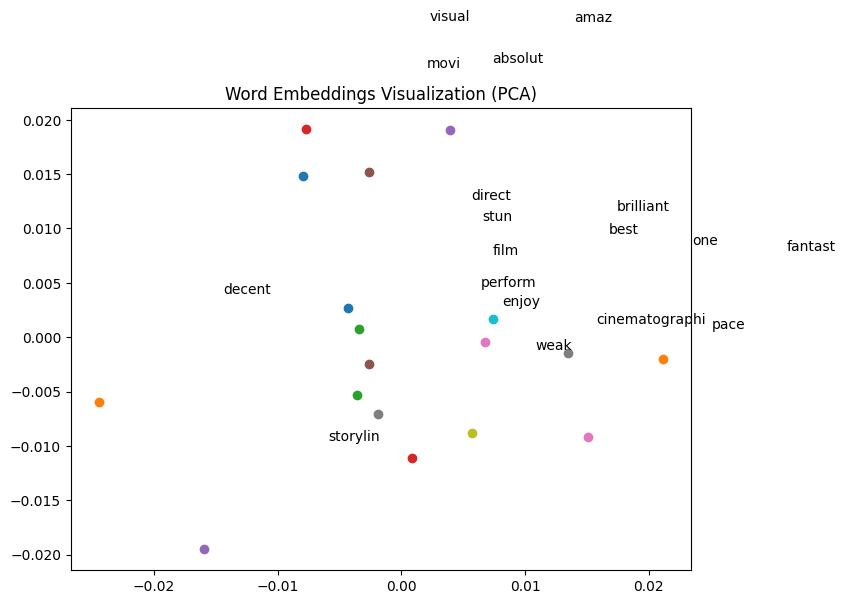

In [21]:
# ==============================
# PCA VISUALIZATION
# ==============================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get some words from vocab
words = list(model.wv.index_to_key[:20])  # top 20 words

# Get vectors
vectors = [model.wv[word] for word in words]

# PCA to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embeddings Visualization (PCA)")
plt.show()

In [22]:
# ==============================
# COSINE SIMILARITY
# ==============================

pairs = [
    ("movi", "film"),
    ("weak", "decent"),
    ("perform", "brilliant"),
    ("direct", "cinematographi"),
    ("fantast", "brilliant")
]

for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        print(f"{w1} vs {w2} = {sim:.4f}")
    else:
        print(f"{w1} or {w2} not in vocabulary")

movi vs film = 0.3031
weak vs decent = 0.2410
perform vs brilliant = 0.1799
direct vs cinematographi = 0.2868
fantast vs brilliant = 0.2249


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


For this task, I selected **sentiment analysis** as the NLP task to perform on my dataset of movie reviews.

The goal of sentiment analysis is to determine the emotional tone of a given piece of text. In this case, I analyzed each movie review and assigned a sentiment label based on whether the review expresses a positive, negative, or neutral opinion.

The labeling schema used for this dataset includes three classes:
1. Positive – Reviews that express favorable opinions, satisfaction, or appreciation for the movie (e.g., words like "great", "amazing", "brilliant").
2. Negative – Reviews that express dissatisfaction, criticism, or dislike (e.g., words like "bad", "worst", "boring").
3. Neutral – Reviews that are balanced, factual, or do not strongly express positive or negative sentiment.

Each review was carefully examined and labeled according to its overall tone. AI assistance was used to help speed up the labeling process, but the labels were verified to ensure consistency and accuracy.

The final dataset was structured into three columns:
- document_id: a unique identifier for each review
- clean_text: the processed text of the review
- sentiment: the assigned sentiment label

This dataset can be used for training and evaluating machine learning models for sentiment classification in future assignments.

For this task, I selected **sentiment analysis** as the NLP task to perform on my dataset of movie reviews.

The goal of sentiment analysis is to determine the emotional tone of a given piece of text. In this case, I analyzed each movie review and assigned a sentiment label based on whether the review expresses a positive, negative, or neutral opinion.

The labeling schema used for this dataset includes three classes:
1. Positive – Reviews that express favorable opinions, satisfaction, or appreciation for the movie (e.g., words like "great", "amazing", "brilliant").
2. Negative – Reviews that express dissatisfaction, criticism, or dislike (e.g., words like "bad", "worst", "boring").
3. Neutral – Reviews that are balanced, factual, or do not strongly express positive or negative sentiment.

Each review was carefully examined and labeled according to its overall tone. AI assistance was used to help speed up the labeling process, but the labels were verified to ensure consistency and accuracy.

The final dataset was structured into three columns:
- document_id: a unique identifier for each review
- clean_text: the processed text of the review
- sentiment: the assigned sentiment label

This dataset can be used for training and evaluating machine learning models for sentiment classification in future assignments.

# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

This assignment was very helpful in understanding practical NLP concepts such as n-grams, TF-IDF, and word embeddings. I especially enjoyed working on the Word2Vec model and visualizing the embeddings, as it helped me see how words are related in a meaningful way.

The most challenging part of the assignment was implementing TF-IDF from scratch and handling some errors while loading and processing the dataset. It required careful attention to preprocessing and calculations.

Overall, the assignment was interesting and gave me hands-on experience with real-world text data. The time provided was generally sufficient, although some parts took longer due to debugging and understanding the concepts in depth.